# 06 - Noise seviyesi karari

Pilotun cevaplamasi gereken soru: **ana deney hangi noise seviyesini
kullansin?**

NB03 betimleyiciydi -- profil, d<sub>z</sub>, kac katilimcida ayni yon.
Burada test var. Analiz birimi **katilimci x kosul** (her hucre 10 trial'in
ortalamasi), butun testler within-subject ve parametrik degil (n = 12).

**Hipotez neydi.** Treviño'nun *stochastic resonance* bulgusu: orta duzey
gorsel noise, esik altindaki bir sinyalin algilanabilirligini artirir ve
performansi **iyilestirir**. Bu bir U (ya da ters-U) sekli demek: uclar
kotu, orta iyi.

**Testi nerede.** Ortogonal polinom kontrastlarinda:

| Kontrast | Agirliklar | Ne sorar |
|---|---|---|
| lineer | −2, −1, 0, +1, +2 | Gurultu arttikca duzenli bir gidis var mi |
| **kuadratik** | +2, −1, −2, −1, +2 | **Ortada tepe/cukur var mi** — SR testi bu |

Karar metrik seti NB03'te secildi: `mae_angle_deg`, `stab_time_s`,
`falls_angle_per_trial`; tie-breaker olarak `control_effort` ve `cart_rms_m`.
Gerekce: `Documentation/Yontem/04_Performans_Metrikleri.md`.

In [1]:
%pip install -q pyyaml pandas numpy pyarrow scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

# Aktif veri seti. config.yaml -> datasets. Setler birbirine karismaz:
# her set kendi data/<dataset>/{raw,interim,processed} agacinda durur.
DATASET = "pilot1"

ANALYSIS_ROOT = Path.cwd()
for _ in range(4):
    if (ANALYSIS_ROOT / "config.yaml").exists():
        break
    ANALYSIS_ROOT = ANALYSIS_ROOT.parent
sys.path.insert(0, str(ANALYSIS_ROOT))

from src import decide as dc
from src import performance as perf

from src.dataset import load_config, dirs

config, ANALYSIS_ROOT = load_config(DATASET, ANALYSIS_ROOT)
RAW_DIR, INTERIM_DIR, PROCESSED_DIR = dirs(config, ANALYSIS_ROOT)
print(f"veri seti: {config['dataset']}  ({config['dataset_label']})")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

trial_df = pd.read_parquet(INTERIM_DIR / "trial_metrics.parquet")
trials_clean = pd.read_parquet(INTERIM_DIR / "trials_clean.parquet")
pc = pd.read_parquet(INTERIM_DIR / "participant_condition.parquet")
pc["noise_level_id"] = pd.Categorical(pc["noise_level_id"],
                                      dc.CONDITION_ORDER, ordered=True)

print(f"katilimci    {pc.participant_id.nunique()}")
print(f"hucre        {len(pc)}  (katilimci x kosul)")
print(f"trial        {len(trial_df)}")
print(f"baseline     {config['performance']['baseline_condition']}")
print(f"karar seti   {', '.join(dc.DECISION_METRICS)}")
print(f"tie-breaker  {', '.join(dc.TIEBREAK_METRICS)}")

katilimci    12
hucre        60  (katilimci x kosul)
trial        600
baseline     no_noise
karar seti   mae_angle_deg, stab_time_s, falls_angle_per_trial
tie-breaker  control_effort, cart_rms_m


## 1. Kosul tablosu

Once ham manzara: her kosulda her metrigin ortalamasi. `yon` sutunu
−1 ise kucuk iyi, +1 ise buyuk iyi, 0 ise belirsiz (o yuzden tie-breaker).

In [3]:
display(dc.decision_table(pc))
print("Kosul siralamasi (1 = en iyi):")
display(dc.condition_ranks(pc))

noise_level_id,yon,no_noise,N1,N2,N3,N4
Mean |theta| (deg),-1,11.247 ±0.978,11.198 ±0.966,12.282 ±0.937,12.508 ±0.895,12.658 ±0.849
Stabilizasyon suresi (s / 20 s),1,18.366 ±0.398,18.491 ±0.354,18.047 ±0.383,18.082 ±0.361,18.088 ±0.355
Aci kaynakli dusus / trial,-1,1.6 ±0.583,1.467 ±0.579,1.775 ±0.677,1.7 ±0.619,2.0 ±0.691
Control effort (RMS u),0,0.206 ±0.011,0.209 ±0.012,0.209 ±0.01,0.2 ±0.012,0.208 ±0.013
Cart RMS pozisyon (m),0,1.09 ±0.075,1.126 ±0.069,1.017 ±0.085,1.144 ±0.078,1.043 ±0.075


Kosul siralamasi (1 = en iyi):


noise_level_id,no_noise,N1,N2,N3,N4
Mean |theta| (deg),2.0,1.0,3.0,4.00,5.00
Stabilizasyon suresi (s / 20 s),2.0,1.0,5.0,4.00,3.00
Aci kaynakli dusus / trial,2.0,1.0,4.0,3.00,5.00
ortalama sira,2.0,1.0,4.0,3.67,4.33


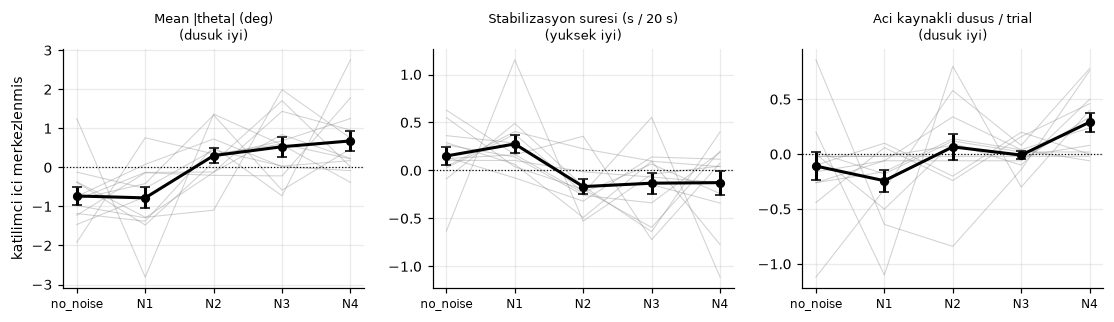

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.0))
for ax, m in zip(axes, dc.DECISION_METRICS):
    w = dc._wide(pc, m)
    cen = w.sub(w.mean(axis=1), axis=0)          # katilimci ici merkezleme
    mu, se = cen.mean(), cen.sem()
    x = range(len(mu))
    for _, r in cen.iterrows():
        ax.plot(x, r.to_numpy(), color="gray", lw=.7, alpha=.35)
    ax.errorbar(x, mu.to_numpy(), yerr=se.to_numpy(), color="k", lw=2,
                marker="o", ms=5, capsize=3, zorder=5)
    ax.axhline(0, color="k", lw=.8, ls=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(list(w.columns), fontsize=8)
    lbl, direction = perf.METRIC_INFO[m]
    ax.set_title(f"{lbl}\n({'yuksek iyi' if direction > 0 else 'dusuk iyi'})",
                 fontsize=8.5)
axes[0].set_ylabel("katilimci ici merkezlenmis")
plt.tight_layout()
plt.show()

## 2. Omnibus: bes kosul arasinda fark var mi

Friedman, within-subject tekrarli olcum icin sirali (non-parametrik) test.
Kendall's W etki buyuklugu: 0 = katilimcilar arasinda hicbir uyum yok,
1 = hepsi kosullari ayni sirada.

In [5]:
display(dc.omnibus_table(pc))

,metrik,n,friedman_chi2,p,kendall_W
kolon,,,,,
mae_angle_deg,Mean |theta| (deg),12,17.800,0.001350,0.371
stab_time_s,Stabilizasyon suresi (s / 20 s),12,11.531,0.021198,0.240
falls_angle_per_trial,Aci kaynakli dusus / trial,12,14.806,0.005122,0.308
control_effort,Control effort (RMS u),12,1.933,0.748019,0.040
cart_rms_m,Cart RMS pozisyon (m),12,7.133,0.129008,0.149


## 3. Sekil: lineer mi kuadratik mi

**Bu notebook'un en onemli hucresi.** Stochastic resonance kuadratik
sutunda gorunurdu.

In [6]:
display(dc.contrast_tests(pc))

,metrik,yon,lineer,lineer_p,lineer_n_ayni_yon,kuadratik,kuadratik_p,n
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,4.1304,0.000488,12,-0.4603,0.622070,12
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.9649,0.004883,10,0.2413,0.569336,12
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,1.0333,0.000977,11,0.4833,0.582520,12
control_effort,Control effort (RMS u),0,-0.0053,1.000000,6,0.0009,0.380371,12
cart_rms_m,Cart RMS pozisyon (m),0,-0.0757,0.677246,6,-0.0373,1.000000,12


Uc karar metriginde de **lineer anlamli, kuadratik degil**. `mae_angle_deg`'de
lineer kontrast 12 katilimcinin 12'sinde ayni yonde. Yani gurultu arttikca
duzenli bir bozulma var, ortada tepe yok.

**Stochastic resonance bu pilotta desteklenmiyor.**

Tie-breaker metrikler (`control_effort`, `cart_rms_m`) hicbir sekilde
ayrismiyor — zaten yonu belirsiz olduklari icin karar setine girmemislerdi.

## 4. Hangi seviye baseline'dan farkli

Her noise kosulu `no_noise` ile eslesmis Wilcoxon. Holm duzeltmesi bir
metrigin dort karsilastirmasi icinde yapiliyor.

`rank_biserial` etki buyuklugu: sifir olmayan farklarin siralamasinda
pozitiflerin payi eksi negatiflerin payi, −1..+1.

In [7]:
for m in dc.DECISION_METRICS:
    lbl, direction = perf.METRIC_INFO[m]
    print(f"{lbl}   ({'yuksek iyi' if direction > 0 else 'dusuk iyi'})")
    display(dc.baseline_tests(pc, m, config))

Mean |theta| (deg)   (dusuk iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,-0.0490,-0.030,0.051,6,0.909668,0.909668
N2,1.0343,1.176,0.872,11,0.004883,0.014648
N3,1.2610,1.172,0.897,11,0.003418,0.013672
N4,1.4102,0.959,0.821,11,0.009277,0.018555


Stabilizasyon suresi (s / 20 s)   (yuksek iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,0.1250,0.203,0.061,6,0.898438,0.898438
N2,-0.3193,-0.827,-0.718,9,0.026855,0.107422
N3,-0.2838,-0.606,-0.615,8,0.063965,0.191895
N4,-0.2781,-0.446,-0.564,10,0.092285,0.191895


Aci kaynakli dusus / trial   (dusuk iyi)


,fark,dz,rank_biserial,n_kotu,p,p_holm
kosul,,,,,,
N1,-0.1333,-0.198,-0.055,6,0.902344,0.984375
N2,0.1750,0.230,0.606,9,0.082031,0.246094
N3,0.1000,0.185,0.289,6,0.492188,0.984375
N4,0.4000,0.724,0.891,9,0.009766,0.039062


**N1 hicbir metrikte baseline'dan farkli degil** (p ≈ 0,90; 12 kisinin
6'sinda bir yonde, 6'sinda diger yonde — yazi tura).

N2/N3/N4 `mae_angle_deg`'de Holm duzeltmesinden sonra da anlamli
(d<sub>z</sub> ≈ 0,96–1,18). Diger iki metrikte duzeltme sonrasi yalniz
N4 ayakta kaliyor — uc metrik ayni seyi olctugu icin bu beklenen bir sey,
aralarindaki fark guc meselesi.

> Not: Holm duzeltmesi metrik **icinde**. Uc karar metrigi birbiriyle guclu
> iliskili (NB03: maPA–RMS r = 0,98), bagimsiz aile sayilmazlar; metrikler
> arasi ek bir duzeltme yapilmadi, yapilsaydi tablo daha muhafazakar olurdu.

## 5. U sekli: kontrast disinda dogrudan bakis

Kuadratik kontrast null cikti ama tek kontrol o olmasin. SR icin **ic**
kosullardan birinin (N1/N2/N3) hem baseline'dan hem N4'ten iyi olmasi
gerekir. Iki sey sayiliyor: grup ortalamasinda en iyi kosul, ve kac
katilimcinin kendi en iyisi bir ic kosul.

In [8]:
display(dc.interior_optimum(pc))

,metrik,grup_en_iyi,grup_en_iyi_ic_mi,kisi_en_iyisi_ic,n,kisi_dagilimi
kolon,,,,,,
mae_angle_deg,Mean |theta| (deg),N1,True,6,12,"N1:6, no_noise:6"
stab_time_s,Stabilizasyon suresi (s / 20 s),N1,True,6,12,"no_noise:6, N1:4, N2:1, N3:1"
falls_angle_per_trial,Aci kaynakli dusus / trial,N1,True,5,12,"no_noise:7, N1:3, N2:2"


Burada dikkat isteyen bir ayrinti var: **grup ortalamasinda uc metrikte de
en iyi kosul N1** — yani sayisal tepe ic bir kosulda. Ama:

- N1 ile baseline arasindaki fark hicbir metrikte anlamli degil (bolum 4)
- kuadratik kontrast null (bolum 3)
- katilimcilarin yaklasik yarisi no_noise, yarisi N1 tercih ediyor

Yani bu bir **U sekli degil**, no_noise ile N1'in ayirt edilemezligi.
Asagidaki composite bunu ozetliyor: kimsenin en iyisi N3 ya da N4 degil.

In [9]:
best = dc.personal_best(pc)
display(best)
print("Kisi basina en iyi kosul dagilimi:")
display(best["en_iyi"].value_counts().rename("n_katilimci").to_frame())

noise_level_id,no_noise,N1,N2,N3,N4,en_iyi
participant_id,,,,,,
P001,-0.014,1.333,-0.523,-1.021,0.225,N1
P002,0.799,0.449,-0.112,0.504,-1.640,no_noise
P003,0.822,0.282,0.457,-0.014,-1.548,no_noise
P004,0.407,0.512,0.111,-0.808,-0.222,N1
P005,0.785,0.377,-1.657,0.477,0.018,no_noise
P006,0.399,0.231,0.974,-1.483,-0.121,N2
P007,1.196,-0.038,-1.249,0.188,-0.096,no_noise
P008,0.144,1.447,-0.803,0.148,-0.936,N1
P009,0.760,0.849,0.140,-0.476,-1.274,N1


Kisi basina en iyi kosul dagilimi:


,n_katilimci
en_iyi,
no_noise,6
N1,5
N2,1


## 6. Duyarlilik: karar neye bagli

Iki kirilganlik testi.

**(a) Kayittaki `valid_trial`.** Unity 600 measurement trial'in 2'sini
`paused` diye isaretlemis (P011 T030, T034). NB01'in kalite kontrolu bu
kolona bakmiyor (bilinen acik madde), yani ikisi de analize giriyor.
Cikarinca sonuc degisiyor mu?

In [10]:
trial_df2, n_dropped = dc.drop_invalid_trials(trial_df, trials_clean)
pc2 = perf.participant_condition(trial_df2)
print(f"cikarilan trial: {n_dropped}  ->  kalan {len(trial_df2)}")
display(dc.contrast_tests(pc2, dc.DECISION_METRICS))
display(dc.condition_ranks(pc2))

cikarilan trial: 2  ->  kalan 598


,metrik,yon,lineer,lineer_p,lineer_n_ayni_yon,kuadratik,kuadratik_p,n
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,4.2118,0.000488,12,-0.3878,0.62207,12
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.9733,0.004883,10,0.2377,0.62207,12
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,1.0204,0.000977,11,0.4815,0.58252,12


noise_level_id,no_noise,N1,N2,N3,N4
Mean |theta| (deg),2.0,1.0,3.0,4.00,5.00
Stabilizasyon suresi (s / 20 s),2.0,1.0,5.0,4.00,3.00
Aci kaynakli dusus / trial,2.0,1.0,4.0,3.00,5.00
ortalama sira,2.0,1.0,4.0,3.67,4.33


**(b) Stabilizasyon esigi.** `stab_time_s` bizim esigimizle hesaplaniyor
(|θ| ≤ 30°); kayittaki `within_bounds_time_s` failure limitini kullandigi
icin tavana yapisik ve kosullari ayirt etmiyordu (NB03). Esik bizim
secimimiz oldugu icin karar ona duyarli olmamali.

In [11]:
samples = pd.read_parquet(
    INTERIM_DIR / "samples_built.parquet",
    columns=["participant_id", "noise_level_id", "trial_id",
             "pole_angle_deg", "fixed_delta_time_s", "analysis_include"])
display(dc.threshold_sensitivity(samples, config, [10, 15, 20, 25, 30, 45]))

,ortalama_s,en_iyi_kosul,lineer,lineer_p,kuadratik_p
esik_deg,,,,,
10,11.66,no_noise,-3.882,0.000488,0.532227
15,14.50,N1,-3.142,0.000488,0.380371
20,16.27,no_noise,-2.048,0.002441,0.569336
25,17.43,no_noise,-1.542,0.000977,0.518555
30,18.21,N1,-0.965,0.004883,0.569336
45,19.43,N1,-0.346,0.006836,0.423828


Iki kontrol de temiz: iki trial'in cikarilmasi hicbir p degerini
oynatmiyor, ve **her esikte lineer anlamli, kuadratik hicbirinde degil**.
En iyi kosul esige gore no_noise ile N1 arasinda gidip geliyor — zaten
ayirt edilemez olduklarinin bir baska gostergesi.

## 7. Karar

In [12]:
stats_all = dc.contrast_tests(pc).join(
    dc.omnibus_table(pc)[["friedman_chi2", "p", "kendall_W"]]
      .rename(columns={"p": "friedman_p"}))
table = dc.decision_table(pc)
display(stats_all[["metrik", "yon", "lineer", "lineer_p",
                   "kuadratik", "kuadratik_p", "friedman_p", "kendall_W"]])
info = dc.save_outputs(stats_all, table, INTERIM_DIR,
                       PROCESSED_DIR / "karar")
print(info)

,metrik,yon,lineer,lineer_p,kuadratik,kuadratik_p,friedman_p,kendall_W
kolon,,,,,,,,
mae_angle_deg,Mean |theta| (deg),-1,4.1304,0.000488,-0.4603,0.622070,0.001350,0.371
stab_time_s,Stabilizasyon suresi (s / 20 s),1,-0.9649,0.004883,0.2413,0.569336,0.021198,0.240
falls_angle_per_trial,Aci kaynakli dusus / trial,-1,1.0333,0.000977,0.4833,0.582520,0.005122,0.308
control_effort,Control effort (RMS u),0,-0.0053,1.000000,0.0009,0.380371,0.748019,0.040
cart_rms_m,Cart RMS pozisyon (m),0,-0.0757,0.677246,-0.0373,1.000000,0.129008,0.149


{'decision_stats.csv': 5, 'decision_table.csv': 5, 'dizin': 'C:\\Users\\elifa\\Documents\\GitHub\\NOROM_Inv_Pendulum\\Data Analysis\\data\\processed\\karar'}


### Bulgu

1. **Stochastic resonance desteklenmiyor.** Kuadratik kontrast uc karar
   metriginde de null (p = 0,57–0,62). Lineer kontrast ucunde de anlamli
   ve ayni yonde: gurultu arttikca performans duzenli olarak bozuluyor.
2. **N1 (σ = 0,02) baseline'dan ayirt edilemiyor.** Uc metrikte de p ≈ 0,90,
   d<sub>z</sub> ≤ 0,20, 12 kisinin 6'si. Sayisal olarak ucunde de en iyi
   kosul N1 ama fark gurultunun icinde.
3. **N2'den itibaren bozulma gercek.** `mae_angle_deg`'de N2/N3/N4 Holm
   sonrasi anlamli, d<sub>z</sub> ≈ 0,96–1,18, 12 kisinin 11'i ayni yonde.
4. **Kimsenin en iyisi N3 ya da N4 degil.** Composite'te 6 kisi no_noise,
   5 kisi N1, 1 kisi N2.

### Ana deney icin aday siralamasi

**1. aday — N1 (σ = 0,02).** Gorsel gurultu var ama performansi olculebilir
sekilde bozmuyor. "Gurultu altinda ogrenme" sorusu, gurultunun anlik
performansi zaten yikmadigi bir seviyede sorulmali; aksi halde ogrenme
farki ile performans bozulmasi birbirine karisir.

**2. aday — N2 (σ = 0,05).** Etkisi olculebilir olan en dusuk seviye
(d<sub>z</sub> ≈ 1,18). Sorunun "gurultu ogrenmeyi bozuyor mu" seklinde
kurulmasi durumunda tercih edilir, ama anlik performansi da bozdugu icin
iki etki ayrisamayabilir.

**N3 ve N4 elenmeli.** N4 zaten en kotu; N3 ile N4 arasinda anlamli fark
yok, yani daha yuksek gurultu ek bilgi getirmiyor.

### Bu karar bir soruya bagli

Ana deney **tek noise seviyesi + no_noise kontrol grubu** mu kullanacak,
yoksa **herkes ayni noise'u** mu alacak? Ekibe soruldu, cevap gelmedi.

- Kontrol grubu varsa: N1 vs no_noise **cok yakin** oldugu icin muhtemelen
  fark cikmaz; boyle bir tasarim icin N2 daha bilgilendirici.
- Herkes ayni noise'u aliyorsa: gurultu ogrenmenin kendisini olcmeyi
  engellememeli, yani N1.

Yani cevaba gore aday sirasi **degisiyor**. Bu notebook her iki durum icin
gereken sayilari uretti.

### Pilot kararina girmeyenler

- **Action timing** (NB04): koşullar arasinda ayirt edici degil, karar
  setinde yok.
- **Sure metrikleri** (NB03): `mean_episode_s` dusus sayisinin deterministik
  donusumu, T/T₀ baslangic acisi kirliligini artiriyor.
- **sIQR'lar** (NB03): RMS'in kopyasi.